In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving amazon.csv to amazon.csv
User uploaded file "amazon.csv" with length 4744481 bytes


In [2]:
import pandas as pd #Load the dataset
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("amazon.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.shape

(1465, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [5]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [8]:
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [9]:
df['actual_price'] = (  #Clean actual price
    df['actual_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [10]:
df['discount_percentage'] = ( #Clean discount percentage
    df['discount_percentage']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [11]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce') #Clean rating

In [12]:
df['rating_count'] = (  #Clean rating count
    df['rating_count']
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

**Data quality**

In [14]:
df.isnull().sum() #Missing values

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,1
rating_count,2
about_product,0
user_id,0


In [15]:
df['product_id'].duplicated().sum() #Duplicate products

np.int64(114)

In [16]:
df[['actual_price',
    'discounted_price',
    'discount_percentage',
    'rating',
    'rating_count']].describe()

,actual_price,discounted_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,5444.990635,3125.310874,47.691468,4.096585,18295.541353
std,10874.826864,6944.304394,21.635905,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,800.000000,325.000000,32.000000,4.000000,1186.000000
50%,1650.000000,799.000000,50.000000,4.100000,5179.000000
75%,4295.000000,1999.000000,63.000000,4.300000,17336.500000
max,139900.000000,77990.000000,94.000000,5.000000,426973.000000


In [17]:
df['discount_amount'] = (
    df['actual_price'] - df['discounted_price']
)

In [18]:
df['main_category'] = df['category'].str.split('|').str[0]

In [19]:
df['main_category'].value_counts()

,count
main_category,
Electronics,526
Computers&Accessories,453
Home&Kitchen,448
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


**Exploratory Data Analysis**

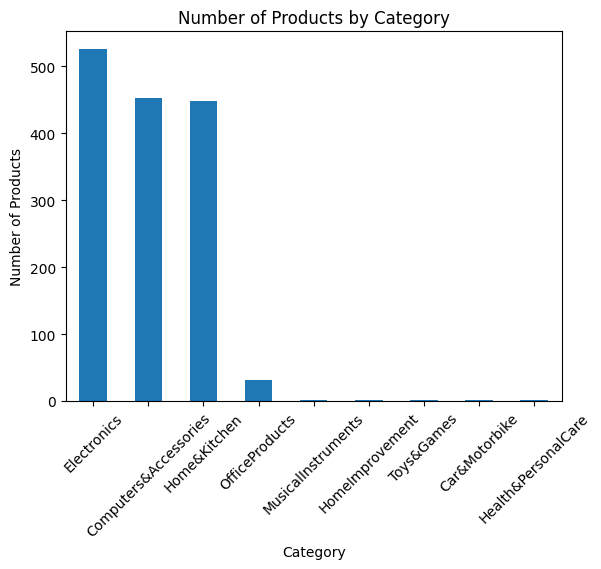

In [20]:
#Which categories have the most products
category_count = df['main_category'].value_counts()

category_count.plot(kind='bar')
plt.title('Number of Products by Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

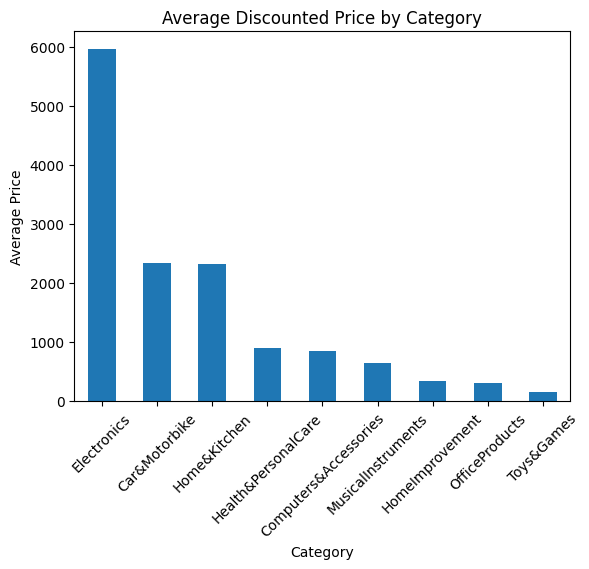

In [21]:
#Which categories have the highest average price
avg_price = df.groupby('main_category')['discounted_price'].mean().sort_values(ascending=False)

avg_price.plot(kind='bar')
plt.title('Average Discounted Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

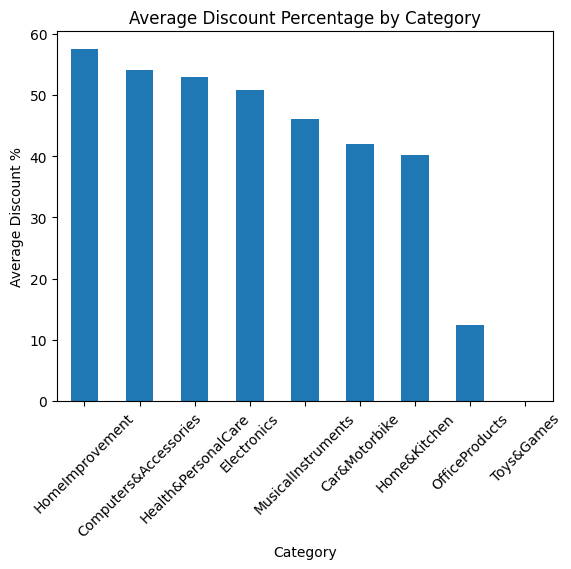

In [22]:
#Which categories offer the highest discounts
avg_discount = df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)

avg_discount.plot(kind='bar')
plt.title('Average Discount Percentage by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount %')
plt.xticks(rotation=45)
plt.show()

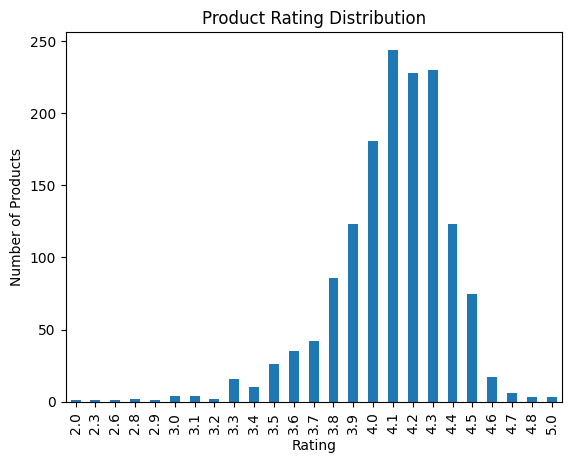

In [23]:
#Rating distribution
df['rating'].value_counts().sort_index().plot(kind='bar')

plt.title('Product Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.show()

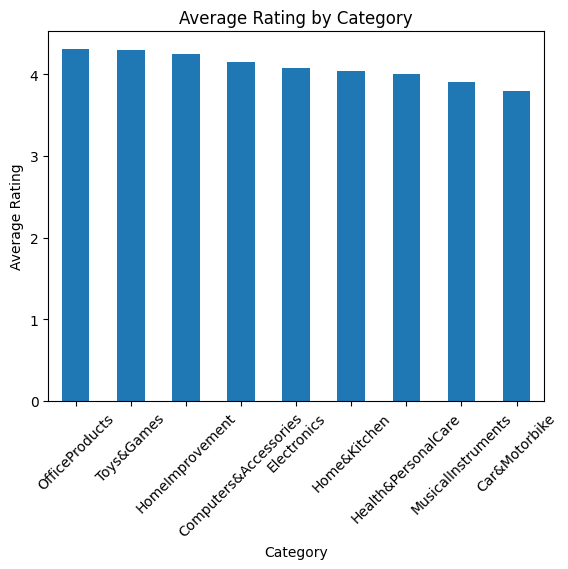

In [24]:
#Average rating by category
avg_rating = df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

avg_rating.plot(kind='bar')
plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

**Customer Engagement Analysis**

In [25]:
#Top 10 most-reviewed products
top_reviewed = df.nlargest(10, 'rating_count')

top_reviewed[['product_name', 'rating_count', 'rating']]

,product_name,rating_count,rating
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0,4.4
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0,4.4
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0,4.4
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0,4.4
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,4.1
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,4.1
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0,4.1
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0,4.1
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0,4.1
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832.0,4.1


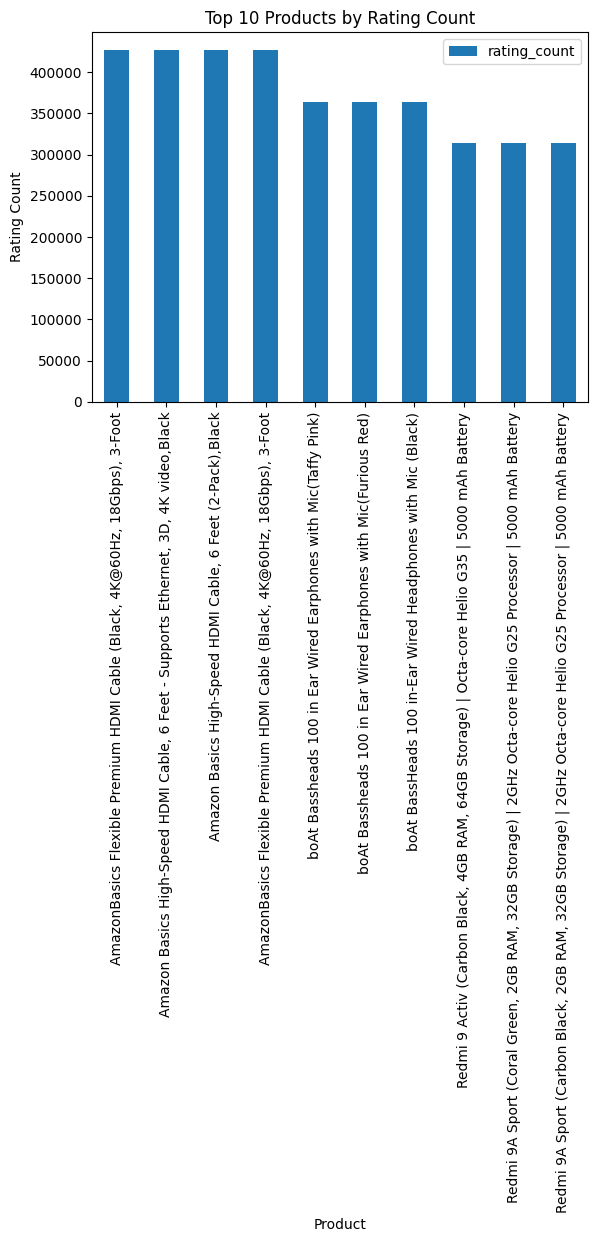

In [26]:
top_reviewed.plot(
    x='product_name',
    y='rating_count',
    kind='bar'
)

plt.title('Top 10 Products by Rating Count')
plt.xlabel('Product')
plt.ylabel('Rating Count')
plt.xticks(rotation=90)
plt.show()

**Relationship Analysis**

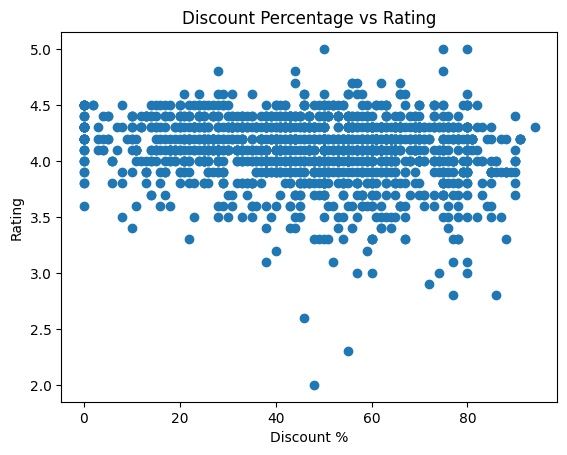

In [27]:
#Discount vs Rating
plt.scatter(
    df['discount_percentage'],
    df['rating']
)

plt.title('Discount Percentage vs Rating')
plt.xlabel('Discount %')
plt.ylabel('Rating')
plt.show()

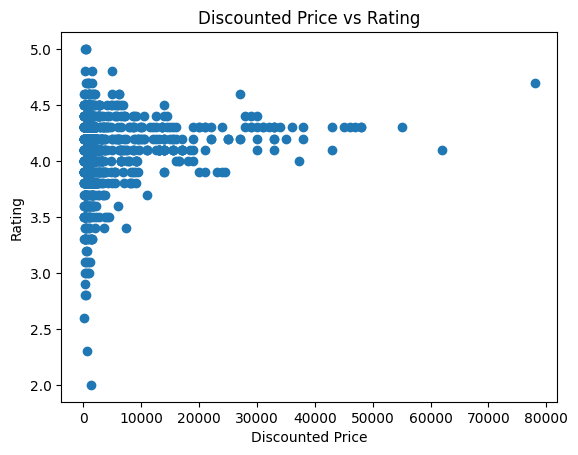

In [28]:
#Price vs Rating
plt.scatter(
    df['discounted_price'],
    df['rating']
)

plt.title('Discounted Price vs Rating')
plt.xlabel('Discounted Price')
plt.ylabel('Rating')
plt.show()

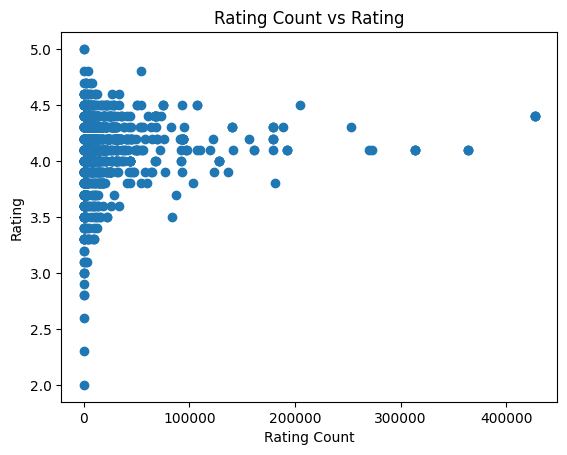

In [29]:
#Rating vs Rating Count
plt.scatter(
    df['rating_count'],
    df['rating']
)

plt.title('Rating Count vs Rating')
plt.xlabel('Rating Count')
plt.ylabel('Rating')
plt.show()

##Business Insights


Insight 1

Which category contains the highest number of products?

Insight 2

Which category has the highest average discounted price?

Insight 3

Which category provides the highest average discount?

Insight 4

Which products receive the highest customer engagement?

Insight 5

Which categories have the highest average ratings?

Insight 6

Does discount percentage appear related to rating?

Insight 7

Does product price appear related to rating?

## Final Business Recommendations

1. Focus on high-performing product categories to improve sales and market performance.

2. Use customer ratings and review counts to identify popular products and understand customer preferences.

3. Review discount strategies carefully and provide competitive discounts without negatively affecting profitability.

4. Promote products with strong customer ratings and high engagement to increase customer trust and visibility.

5. Analyze pricing patterns across categories to maintain competitive and attractive prices.

6. Improve product visibility for categories and products with lower customer engagement.

7. Use customer feedback and ratings regularly to improve product quality and customer satisfaction.

8. Combine product, pricing, discount, and customer engagement analysis to support better business decisions.